<a href="https://colab.research.google.com/github/Viktoriia-code26/goit_telecom-churn-prediction/blob/main/Project_eda_train_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
df = pd.read_csv("/content/drive/MyDrive/internet_service_churn.csv")
df.head()


,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   reamining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


In [4]:
df.describe()


,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
count,7.227400e+04,72274.000000,72274.000000,72274.000000,72274.000000,50702.000000,72274.000000,71893.000000,71893.000000,72274.000000,72274.000000
mean,8.463182e+05,0.815259,0.334629,2.450051,18.942483,0.716039,0.274234,43.689911,4.192076,0.207613,0.554141
std,4.891022e+05,0.388090,0.471864,2.034990,13.215386,0.697102,0.816621,63.405963,9.818896,0.997123,0.497064
min,1.500000e+01,0.000000,0.000000,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.222165e+05,1.000000,0.000000,0.930000,13.000000,0.000000,0.000000,6.700000,0.500000,0.000000,0.000000
50%,8.477840e+05,1.000000,0.000000,1.980000,19.000000,0.570000,0.000000,27.800000,2.100000,0.000000,1.000000
75%,1.269562e+06,1.000000,1.000000,3.300000,22.000000,1.310000,0.000000,60.500000,4.800000,0.000000,1.000000
max,1.689744e+06,1.000000,1.000000,12.800000,406.000000,2.920000,19.000000,4415.200000,453.300000,7.000000,1.000000


In [5]:
# Пропуски будем обрабатывать после разделения данных
# на train и test, чтобы избежать data leakage

In [6]:
# Проверяем, связан ли факт пропуска remaining_contract с churn
df.groupby(
    df["reamining_contract"].isna()
)["churn"].agg(["mean", "count"])

,mean,count
reamining_contract,,
False,0.400990,50702
True,0.914102,21572


In [7]:
df["remaining_contract_missing"] = (
    df["reamining_contract"].isna().astype(int)
)

In [8]:
df.isnull().sum()

,0
id,0
is_tv_subscriber,0
is_movie_package_subscriber,0
subscription_age,0
bill_avg,0
reamining_contract,21572
service_failure_count,0
download_avg,381
upload_avg,381
download_over_limit,0


In [9]:
df["remaining_contract_missing"].value_counts()

,count
remaining_contract_missing,
0,50702
1,21572


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

,0
id,int64
is_tv_subscriber,int64
is_movie_package_subscriber,int64
subscription_age,float64
bill_avg,int64
reamining_contract,float64
service_failure_count,int64
download_avg,float64
upload_avg,float64
download_over_limit,int64


In [12]:
df.shape

(72274, 12)

In [13]:
# Подготовка данных к модели
X = df.drop(columns=["id", "churn"])
y = df["churn"]

print(X.shape)
print(y.shape)

(72274, 10)
(72274,)


In [40]:
df[df["subscription_age"] < 0]["subscription_age"].describe()

,subscription_age
count,1.00
mean,-0.02
std,NaN
min,-0.02
25%,-0.02
50%,-0.02
75%,-0.02
max,-0.02


In [41]:
print("Negative values:",
      (df["subscription_age"] < 0).sum())

print("Percentage:",
      (df["subscription_age"] < 0).mean() * 100)

Negative values: 1
Percentage: 0.001383623433046462


In [42]:
df.loc[
    df["subscription_age"] < 0,
    ["subscription_age", "churn"]
].head(20)

,subscription_age,churn
69320,-0.02,1


In [43]:
# Replace invalid negative subscription age with 0
df.loc[df["subscription_age"] < 0, "subscription_age"] = 0

In [44]:
print("Negative values:",
      (df["subscription_age"] < 0).sum())

print("Minimum subscription age:",
      df["subscription_age"].min())

Negative values: 0
Minimum subscription age: 0.0


Subscription age anomaly:
One negative value (-0.02) was detected in the subscription_age feature, representing approximately 0.0014% of the dataset. Since subscription duration cannot be negative, this value was considered invalid and replaced with 0.

In [45]:
# Делим данные на test_data and train_data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [46]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (57819, 10)
X_test: (14455, 10)
y_train: (57819,)
y_test: (14455,)


In [47]:
print(X_train.isnull().sum())

is_tv_subscriber                   0
is_movie_package_subscriber        0
subscription_age                   0
bill_avg                           0
reamining_contract             17214
service_failure_count              0
download_avg                     296
upload_avg                       296
download_over_limit                0
remaining_contract_missing         0
dtype: int64


In [48]:
print(type(X_train))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


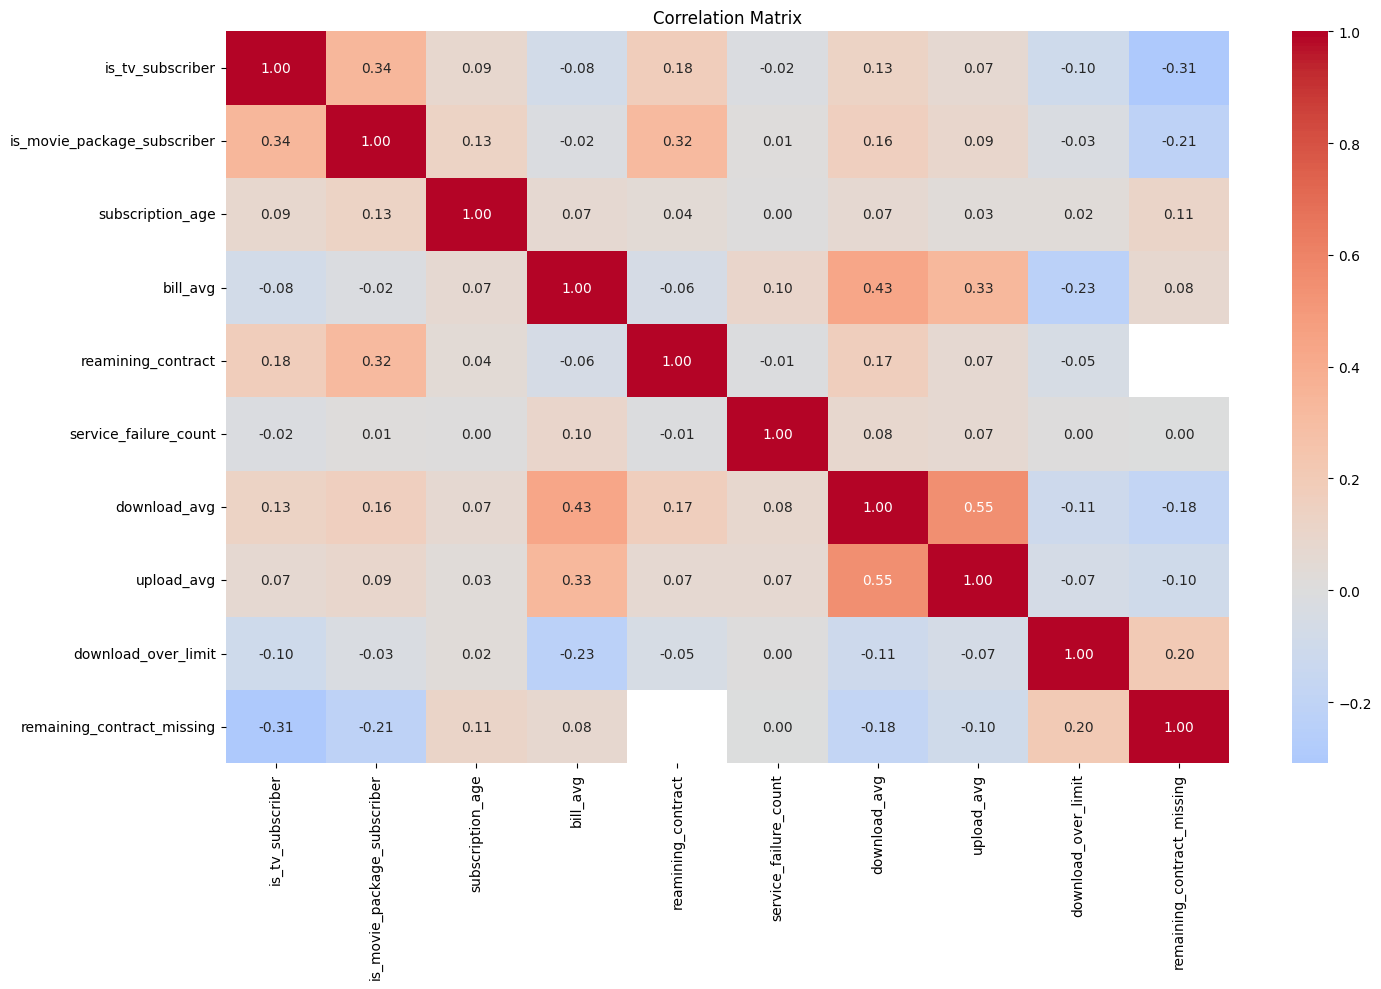

In [49]:
plt.figure(figsize=(15, 10))

corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", center=0)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Заполняем средним
mean_cols = ["download_avg", "upload_avg"]

# Для remaining_contract заполняем пропуски нулём.
# При этом отдельный remaining_contract_missing
# сохраняет информацию о том, что изначально был NaN.
zero_cols = ["reamining_contract"]

# Остальные признаки оставляем без изменений
other_cols = [
    col for col in X_train.columns
    if col not in mean_cols + zero_cols
]

preprocessor = ColumnTransformer(
    transformers=[
        ("mean_imputer", SimpleImputer(strategy="mean"), mean_cols),
        ("zero_imputer", SimpleImputer(strategy="constant", fill_value=0), zero_cols),
        ("other", "passthrough", other_cols)
    ]
)

# ***Logistic Regression***

In [51]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="liblinear"
    ))
])

In [52]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"]
}

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best CV F1:", grid_lr.best_score_)

Best parameters: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV F1: 0.8926246475264513


In [53]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

best_model_lr = grid_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_test)
y_pred_proba_lr = best_model_lr.predict_proba(X_test)[:, 1]

lr_cm = confusion_matrix(y_test, y_pred_lr)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 score:", f1_score(y_test, y_pred_lr))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_proba_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.8763057765479073
Precision: 0.8746387283236994
Recall: 0.9067415730337078
F1 score: 0.890400882677455
ROC AUC score: 0.9310420934266612
Confusion matrix:
 [[5404 1041]
 [ 747 7263]]
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86      6445
           1       0.87      0.91      0.89      8010

    accuracy                           0.88     14455
   macro avg       0.88      0.87      0.87     14455
weighted avg       0.88      0.88      0.88     14455



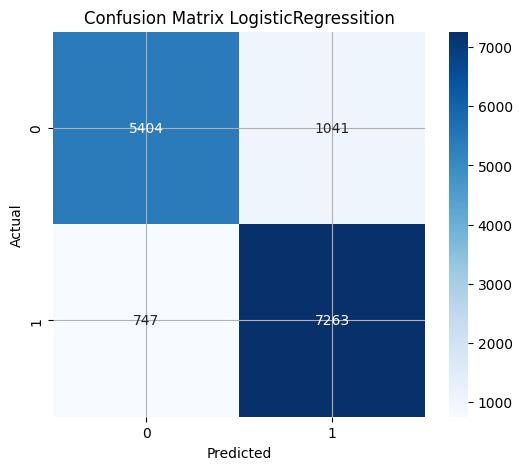

In [54]:

plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix LogisticRegressition")
plt.grid()
plt.show()

Logistic Regression показала высокое качество классификации на тестовой выборке: Accuracy = 0.876, F1-score = 0.890 и ROC-AUC = 0.931. Recall для класса churn составил 0.907, то есть модель корректно определила около 90.7% клиентов, которые действительно ушли. Из 8010 клиентов с churn модель правильно классифицировала 7263 и пропустила 747. При этом 1041 клиент был ошибочно отнесён к классу churn. Полученные результаты показывают, что Logistic Regression хорошо различает клиентов с оттоком и без него.

# ***RandomForestClassifier***

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [56]:
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV F1:", grid_rf.best_score_)

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1: 0.9464365590949024


In [57]:
best_model_rf = grid_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)
y_pred_proba_rf = best_model_rf.predict_proba(X_test)[:, 1]

rf_cm = confusion_matrix(y_test, y_pred_rf)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 score:", f1_score(y_test, y_pred_rf))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_proba_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9411276374956762
Precision: 0.9567436519076177
Recall: 0.936079900124844
F1 score: 0.9462989840348331
ROC AUC score: 0.9819881180332188
Confusion matrix:
 [[6106  339]
 [ 512 7498]]
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      6445
           1       0.96      0.94      0.95      8010

    accuracy                           0.94     14455
   macro avg       0.94      0.94      0.94     14455
weighted avg       0.94      0.94      0.94     14455



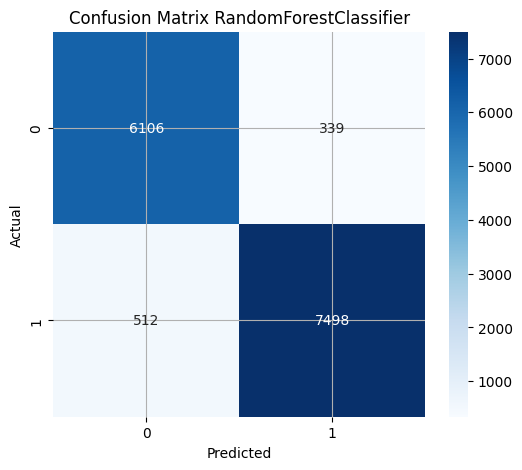

In [58]:
rf_cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix RandomForestClassifier")
plt.grid()
plt.show()

Random Forest показал более высокие результаты по сравнению с Logistic Regression по всем рассмотренным метрикам. На тестовой выборке F1-score составил 0.946, а ROC-AUC — 0.982. Recall для класса churn равен 0.936, то есть модель обнаружила около 93.6% клиентов, которые действительно ушли. По сравнению с Logistic Regression количество false negative снизилось с 747 до 512, а false positive — с 1041 до 339. Таким образом, Random Forest лучше справляется с классификацией оттока на данной тестовой выборке.

In [59]:
# Получаем обученную модель
rf_model = best_model_rf.named_steps["model"]

# Названия признаков после preprocessing
feature_names = (
    best_model_rf
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Важность признаков
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
2,zero_imputer__reamining_contract,0.582745
0,mean_imputer__download_avg,0.115065
9,other__remaining_contract_missing,0.082081
1,mean_imputer__upload_avg,0.075433
5,other__subscription_age,0.054124
6,other__bill_avg,0.046604
4,other__is_movie_package_subscriber,0.018780
3,other__is_tv_subscriber,0.017969
7,other__service_failure_count,0.005056
8,other__download_over_limit,0.002143


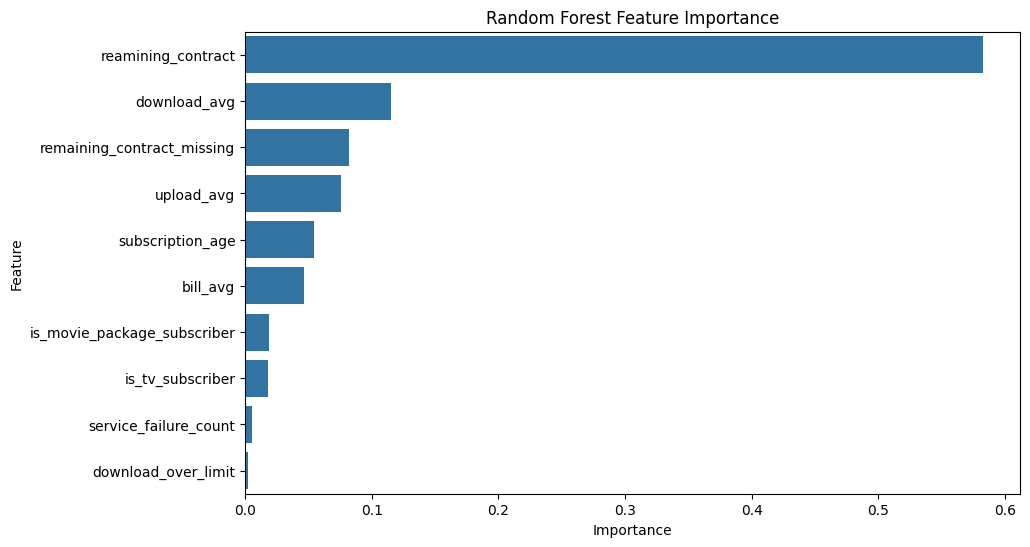

In [60]:
feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace("zero_imputer__", "", regex=False)
    .str.replace("mean_imputer__", "", regex=False)
    .str.replace("other__", "", regex=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Анализ важности признаков Random Forest показал, что наибольший вклад в прогнозирование оттока вносит reamining_contract. Существенную роль также играют download_avg и созданный признак remaining_contract_missing. Это подтверждает, что информация о наличии пропуска в reamining_contract является полезной для модели и её сохранение в отдельном бинарном признаке было обоснованным. Меньший вклад в прогноз вносят upload_avg, subscription_age и bill_avg, тогда как service_failure_count и download_over_limit практически не влияют на предсказания Random Forest.

# ***Model Performance Comparison***

In [61]:
results = pd.DataFrame(
    {"Models": ["Logistic Regression",
                "Random Forest"],
     "Accuracy": [acc_lr, acc_rf],
     "Precision": [prec_lr, prec_rf],
     "Recall": [rec_lr, rec_rf],
     "F1": [f1_lr, f1_rf],
     "ROC-AUC": [auc_lr, auc_rf]})
results = results.set_index("Models")
results.sort_values(by="F1", ascending=False, inplace=True)
results

,Accuracy,Precision,Recall,F1,ROC-AUC
Models,,,,,
Random Forest,0.941128,0.956744,0.936080,0.946299,0.981988
Logistic Regression,0.876306,0.874639,0.906742,0.890401,0.931042


## Summary of Model ***Performance***

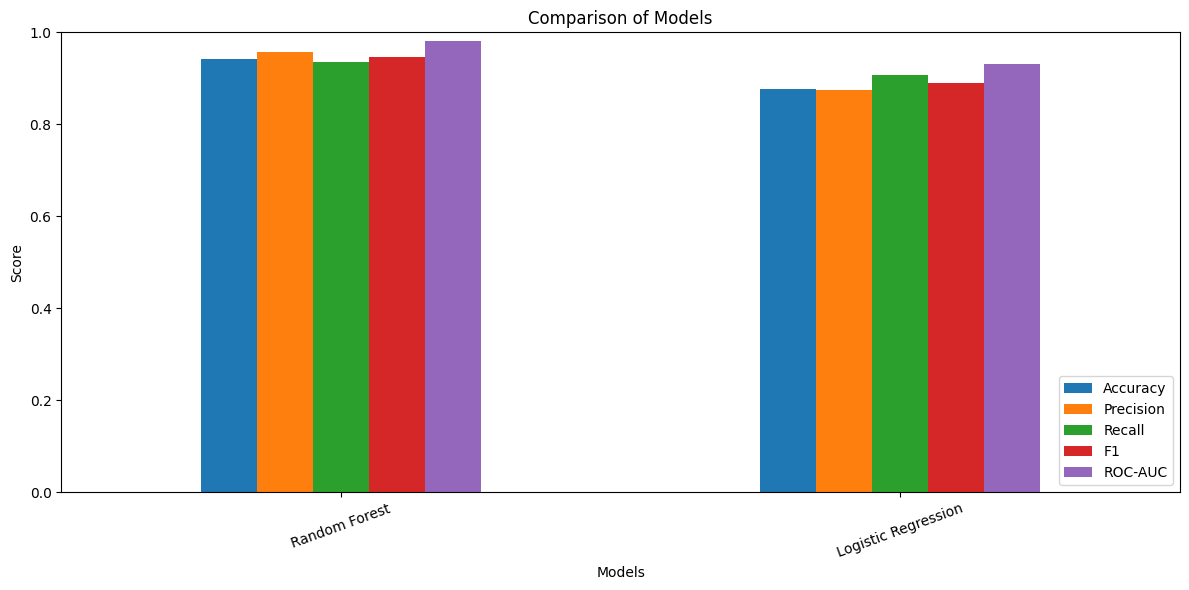

In [62]:
results.plot(kind="bar", figsize=(12, 6))
plt.title("Comparison of Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ROC Curve **Comparison**

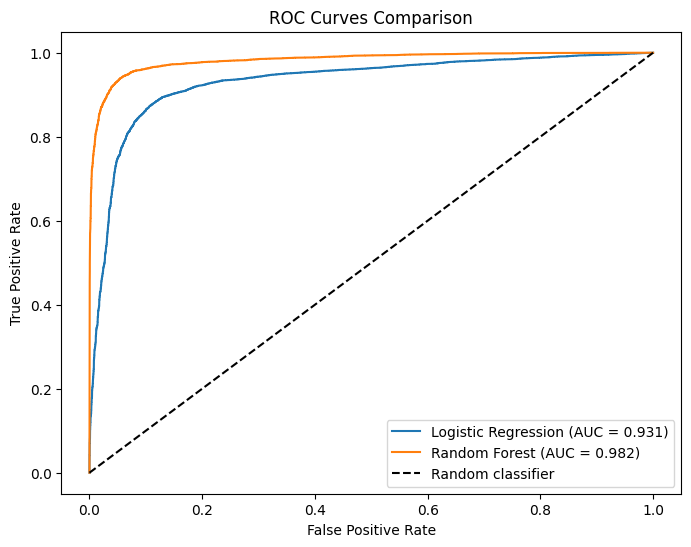

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# Случайный классификатор
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

## Conclusion

In this project, two machine learning models were trained and evaluated to predict customer churn: **Logistic Regression** and **Random Forest**.

### Model Comparison

Logistic Regression achieved an **F1-score of 0.890** and a **ROC-AUC of 0.931**, showing good performance in identifying customers who are likely to churn.

Random Forest demonstrated better performance on the test set, achieving:

- **Accuracy:** 0.941
- **Precision:** 0.957
- **Recall:** 0.936
- **F1-score:** 0.946
- **ROC-AUC:** 0.982

The Random Forest model correctly identified **7,498 out of 8,010** customers who churned, while 512 churn cases were missed.

### Feature Importance

The feature importance analysis showed that **remaining_contract** was the most influential feature in the Random Forest model.

The missing values in `remaining_contract` were also found to contain useful information. Customers with missing values had a substantially higher churn rate, so an additional binary feature, `remaining_contract_missing`, was created to preserve this information.

Other relevant features included `download_avg`, `upload_avg`, `subscription_age`, and `bill_avg`.

### Final Result

Based on the test-set metrics, **Random Forest outperformed Logistic Regression across all evaluated metrics** in this experiment.

The results suggest that information related to the remaining contract period, including whether this information is missing, is particularly useful for predicting customer churn.

# ***Model Integration and Prediction for a New Customer***

In [66]:
def predict_churn(customer_data):
    customer = pd.DataFrame([customer_data])

    # Создаём тот же признак, который использовался при обучении
    customer["remaining_contract_missing"] = (
        customer["reamining_contract"].isna().astype(int)
    )

    # Сохраняем тот же порядок признаков
    customer = customer[X_train.columns]

    prediction = best_model_rf.predict(customer)[0]
    probability = best_model_rf.predict_proba(customer)[0, 1]

    if prediction == 1:
        result = "High churn risk"
    else:
        result = "Low churn risk"

    return {
        "prediction": int(prediction),
        "churn_probability": round(float(probability), 3),
        "result": result
    }

In [67]:
# Prospective new client questionnaire
new_customer = {
    "is_tv_subscriber": 1,
    "is_movie_package_subscriber": 0,
    "subscription_age": 2.5,
    "bill_avg": 20.0,
    "reamining_contract": 0.5,
    "service_failure_count": 1,
    "download_avg": 35.0,
    "upload_avg": 5.0,
    "download_over_limit": 0
}


In [68]:
# Output of results
result = predict_churn(new_customer)

print(f"Churn probability: {result['churn_probability']:.1%}")
print(f"Prediction: {result['result']}")

Churn probability: 18.7%
Prediction: Low churn risk


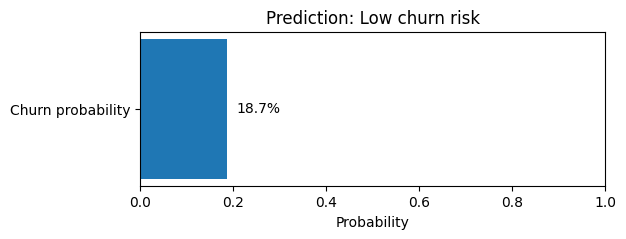

In [69]:
# probability plot
import matplotlib.pyplot as plt

probability = result["churn_probability"]

plt.figure(figsize=(6, 2))
plt.barh(["Churn probability"], [probability])
plt.xlim(0, 1)

plt.text(
    probability + 0.02,
    0,
    f"{probability:.1%}",
    va="center"
)

plt.title(f"Prediction: {result['result']}")
plt.xlabel("Probability")
plt.show()

In [71]:
import joblib

joblib.dump(best_model_rf, "churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!
